# Portfolio Analyzer

**Author:** Yusuf Ardahan Dogru  
**Date:** December 2025  
**Purpose:** Analyze multi-asset portfolios using Modern Portfolio Theory

## Overview
This notebook explores implementations and outcomes of portfolio optimization techniques that the author is curious about; including:
- Risk-return analysis
- Minimum variance optimization
- Sharpe ratio maximization

The notebook also contains the XGBoost model to forecast stock values

### Library Imports

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


### Style of Visualization

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### Stock and ETF tickers

In [3]:
tickers = [
    # Individual stocks (play around with different stocks)
    'AAPL', 'MSFT', 'GOOGL', 'NVDA', # 4 of the Magnificient 7
    'JPM', 'BAC',                    # finance/banking giants
    'WMT', 'AMZN',                   # retail giants ( + 1 Magnif 7)
    'JNJ', 'UNH',                    # healthcare
    'XOM', 'CVX',                    # oil
    
    # Strategic ETFs
    'SCHG',  # Growth
    'SPMO',  # Momentum
    'SMH',   # Semiconductors
    
    # Benchmarks
    'SPY',   # S&P 500
    'AGG'    # Bonds (consider for diversification)
]

### Get ticker data using yf

In [4]:
start_date = '2020-12-01'
end_date = '2025-12-06'

# auto_adjust=True => modifies historical stock prices so that stock splits and dividends do not artificially distort returns
# progress=False => this just removes the progress bar, just a visual setting
raw_data = yf.download(tickers, start=start_date, end=end_date, progress=False, auto_adjust=True)  


if isinstance(raw_data.columns, pd.MultiIndex):
    data = raw_data['Close'].copy()
else:
    data = raw_data.copy()

print(f"Data shape: {data.shape}")
print(f"Date range: From {data.index[0].date()} to {data.index[-1].date()}")

Data shape: (1260, 17)
Date range: From 2020-12-01 to 2025-12-05


### Handle Missing Values

In [5]:
if (data.isnull().sum()).sum() > 0:
    print(f"\nMissing values per stock:")
    print(data.isnull().sum())
    data = data.ffill()  
# ffill => forward fill => replace with last/preceding val

if len(data) < 100:
    print(f"Warning: Only {len(data)} days of data available")

In [6]:
returns = data.pct_change().dropna()
#pct_change is a pandas Dataframe method, computes: (current_value - previous_value) / previous_value for each column, row by row

print("Daily returns calculated!")
print(f"Shape: {returns.shape}")
print(f"\nSample returns:")
print(returns.head(1))

# Risk-free rate used consistently for every Sharpe ratio in this notebook.
riskFreeRate = 0.04  # 3 month T-bills as the risk-free benchmark.

# Calculate key metrics
annual_returns = returns.mean() * 252  # 252 trading days per year
annual_volatility = returns.std() * np.sqrt(252)
sharpe_ratio = (annual_returns - riskFreeRate) / annual_volatility  # excess return over risk-free, per unit volatility

# Create summary DataFrame
metrics_df = pd.DataFrame({
    'Annual Return (%)': (annual_returns * 100).round(2),
    'Volatility (%)': (annual_volatility * 100).round(2),
    'Sharpe Ratio': sharpe_ratio.round(3)
}).sort_values('Sharpe Ratio', ascending=False)

print("\n" + "="*60)
print("PORTFOLIO METRICS SUMMARY")
print("="*60)
print(metrics_df)

Daily returns calculated!
Shape: (1259, 17)

Sample returns:
Ticker          AAPL       AGG     AMZN       BAC       CVX     GOOGL  \
Date                                                                    
2020-12-02  0.002934 -0.001103 -0.00514  0.012897  0.027673  0.016493   

Ticker          JNJ       JPM      MSFT      NVDA      SCHG       SMH  \
Date                                                                    
2020-12-02  0.00468  0.019208 -0.003885  0.011538 -0.001606  0.004002   

Ticker          SPMO       SPY      UNH       WMT       XOM  
Date                                                         
2020-12-02 -0.003577  0.002104  0.01867 -0.013889  0.037403  

PORTFOLIO METRICS SUMMARY
        Annual Return (%)  Volatility (%)  Sharpe Ratio
Ticker                                                 
NVDA                65.80           52.06         1.187
XOM                 29.92           27.19         0.953
JPM                 24.89           24.18         0.864
GOOGL 

### Check Correlations of Stock With Each Other

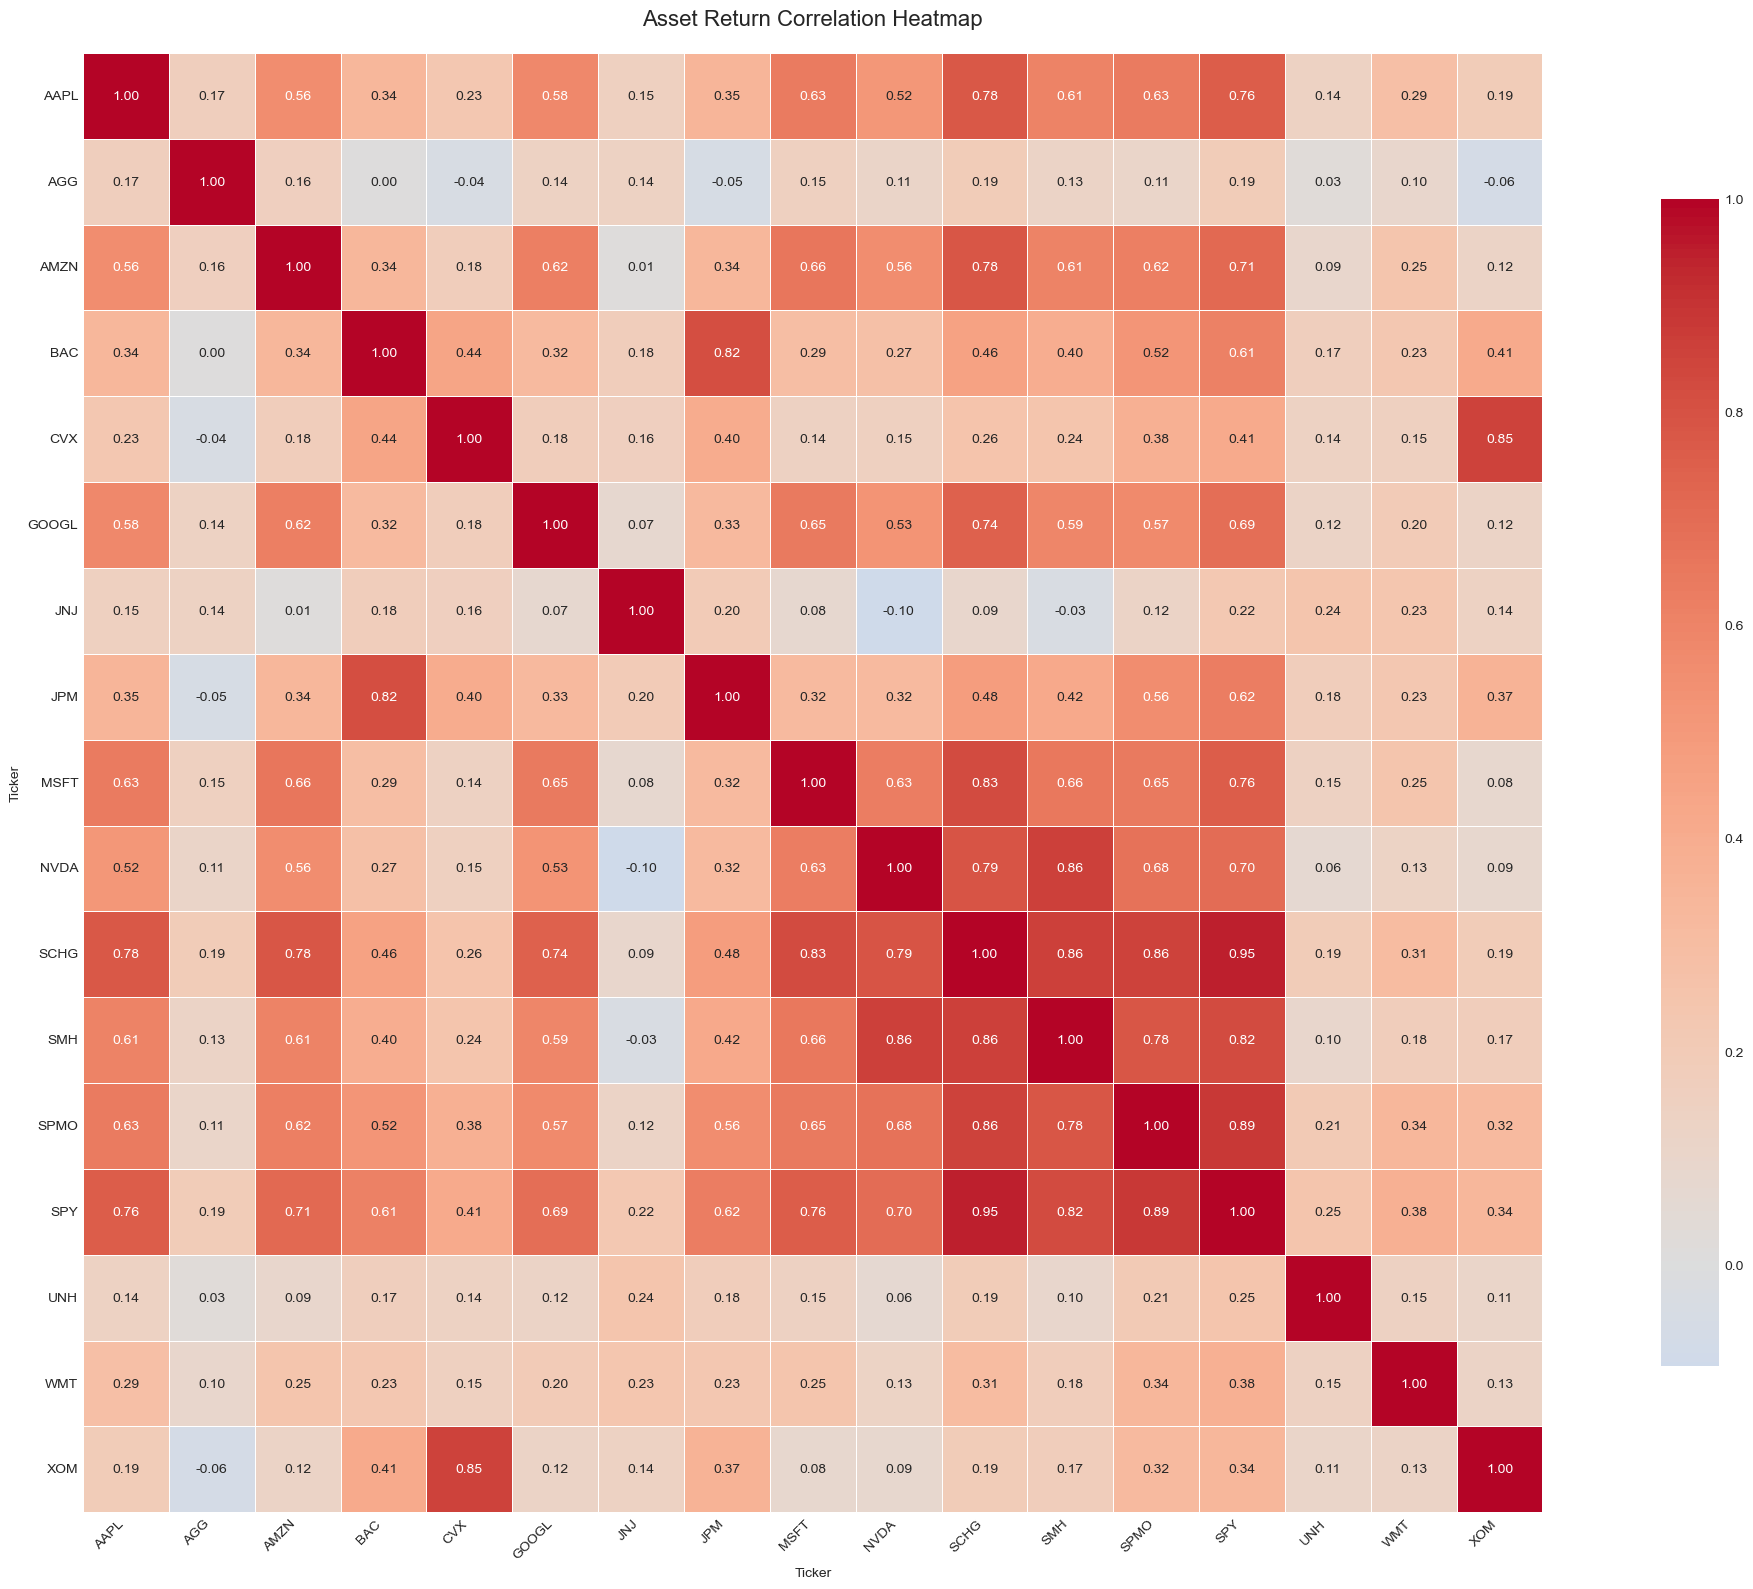

In [7]:
corr_matrix = returns.corr()

plt.figure(figsize=(24, 16))  # Larger figure
sns.heatmap(corr_matrix, 
            cmap='coolwarm', 
            center=0, 
            linewidths=0.5,
            annot=True,  # Show correlation values
            fmt='.2f',   # 2 decimal places
            square=True, # Make cells square
            cbar_kws={'shrink': 0.8})  # Smaller colorbar
plt.title('Asset Return Correlation Heatmap', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')  # Rotate x labels
plt.yticks(rotation=0)
plt.tight_layout()  # Prevent label cutoff
plt.show()

## Construct a fair portfolio (equal allocation in the porfolio for each ticker)

In [8]:
# riskFreeRate is defined once earlier (with the returns/metrics cell) and reused here.

num_assets = returns.shape[1] #num of stock tickers
equal_weights = np.array([1 / num_assets] * num_assets) #equal weights that add upto one

portfolio_returns_fair = returns @ equal_weights # daily returns of fairly allocated portfolio ( 1 / numStocks)

portfolio_vol_fair = portfolio_returns_fair.std() * np.sqrt(252)  # avg daily standard deviation * 252 for annualized volatility
portfolio_return_fair = portfolio_returns_fair.mean() * 252 # avg daily return * 252 to annualize
portfolio_sharpe_fair = (portfolio_return_fair - riskFreeRate) / portfolio_vol_fair  # excess return over risk-free, per unit volatility
print(f"Annualized volatility: {portfolio_vol_fair}")
print(f"Annualized return:{portfolio_return_fair}")
print(f"Annualized sharpe ratio: {portfolio_sharpe_fair}")

Annualized volatility: 0.16944276281237508
Annualized return:0.2135396405384152
Annualized sharpe ratio: 1.0241785347337413


## Optimize Fair Portfolio 

In [9]:
cov_matrix = returns.cov() * 252

def portfolio_volatility(weights):
    return np.sqrt(weights.T @ cov_matrix.values @ weights)

# sum of weights must be equal to 1
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

#each weight is between 0 and 1; a percentage of the portfolio
bounds = tuple((0, 1) for _ in range(num_assets))

from scipy.optimize import minimize

initial_weights = equal_weights

# minimize portfolio volatility using initial weights according to SLSQP method with bounds within 0 and 1 and the constraint above
opt_result = minimize(
    portfolio_volatility,
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

opt_weights = opt_result.x
print(opt_weights)

[6.62653282e-18 8.51533389e-01 1.73505501e-17 9.90838677e-19
 8.73019257e-03 0.00000000e+00 3.80611554e-02 3.54555607e-02
 0.00000000e+00 0.00000000e+00 0.00000000e+00 5.15302273e-18
 6.06774245e-19 5.12763553e-18 1.45913915e-02 2.28154480e-02
 2.88128628e-02]


In [10]:
portfolio_returns_opt = returns @ opt_weights

portfolio_vol_opt = portfolio_returns_opt.std() * np.sqrt(252)
portfolio_return_opt = portfolio_returns_opt.mean() * 252
portfolio_sharpe_opt = (portfolio_return_opt - riskFreeRate) / portfolio_vol_opt  # excess return over risk-free, per unit volatility

print(f"Optimized portfolio's Annualized Volatility:{portfolio_vol_opt}")
print(f"Optimized portfolio's Annualized Return: {portfolio_return_opt}")
print(f"Optimized portfolio's Sharpe Ratio: {portfolio_sharpe_opt}")

Optimized portfolio's Annualized Volatility:0.05613489199412505
Optimized portfolio's Annualized Return: 0.02693698866448346
Optimized portfolio's Sharpe Ratio: -0.23270751704454487


### Risk - Return Results

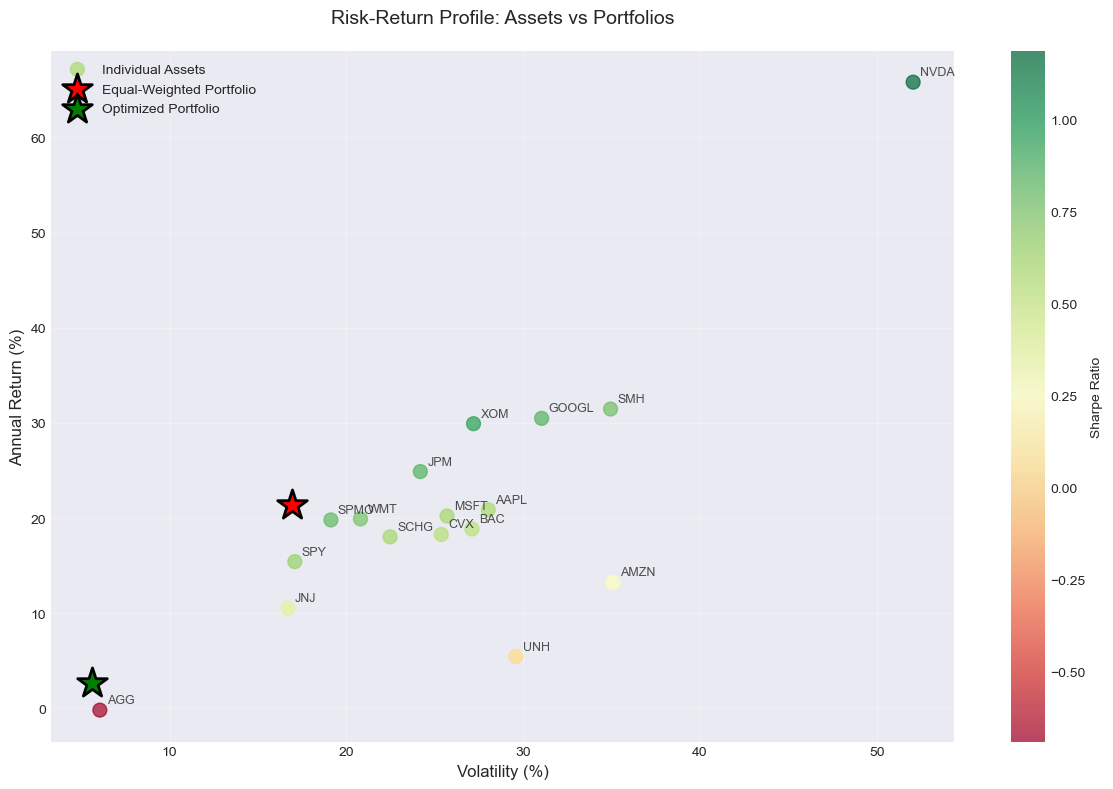

In [11]:
sharpe_ratio = (annual_returns - riskFreeRate) / annual_volatility

# Create the plot
plt.figure(figsize=(12, 8))

# Plot individual assets
plt.scatter(
    annual_volatility * 100,
    annual_returns * 100,
    s=100,
    alpha=0.7,
    c=sharpe_ratio,  # Color by Sharpe ratio
    cmap='RdYlGn',   # Red (low) to Green (high)
    label='Individual Assets'
)
plt.colorbar(label='Sharpe Ratio')

# Annotate each ticker
for ticker in tickers:
    plt.annotate(
        ticker,
        xy=(annual_volatility[ticker] * 100, annual_returns[ticker] * 100),
        xytext=(5, 5),  # Offset the label slightly
        textcoords='offset points',
        fontsize=9,
        alpha=0.8
    )

# Plot portfolios
plt.scatter(
    portfolio_vol_fair * 100,
    portfolio_return_fair * 100,
    marker='*',
    s=500,
    c='red',
    edgecolors='black',
    linewidths=2,
    label='Equal-Weighted Portfolio',
    zorder=5  # Draw on top
)

plt.scatter(
    portfolio_vol_opt * 100,
    portfolio_return_opt * 100,
    marker='*',
    s=500,
    c='green',
    edgecolors='black',
    linewidths=2,
    label='Optimized Portfolio',
    zorder=5
)

plt.xlabel('Volatility (%)', fontsize=12)
plt.ylabel('Annual Return (%)', fontsize=12)
plt.title('Risk-Return Profile: Assets vs Portfolios', fontsize=14, pad=20)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



##  1: Feature Engineering

### Create predictive features from historical data:

In [12]:
def create_features(data, returns, ticker):

    df = pd.DataFrame(index=returns.index)
    print(df.columns)
    # Momentum 
    df['return_5d'] = returns[ticker].rolling(5).mean()
    df['return_20d'] = returns[ticker].rolling(20).mean()
    df['return_60d'] = returns[ticker].rolling(60).mean()
    
    # Volatility 
    df['volatility_20d'] = returns[ticker].rolling(20).std()
    df['volatility_60d'] = returns[ticker].rolling(60).std()
    
    # Volume  (if available)
    # df['volume_ratio'] = volume[ticker] / volume[ticker].rolling(20).mean()
    
    # Market correlation 
    df['corr_to_spy'] = returns[ticker].rolling(60).corr(returns['SPY'])
    
    # Relative strength
    df['rsi_14'] = calculate_rsi(returns[ticker], periods=14)
    
    return df.dropna()

# Answers the question: How strong are the gains compared to the losses over a period?
# also a momentum indicator 
def calculate_rsi(returns, periods=14):
    delta = returns
    gain = (delta.where(delta > 0, 0)).rolling(window = periods).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window = periods).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

### Create target variable (in this case, SPY)

In [13]:
def create_target(returns, ticker, forward_window=20):
    """
    Will this stock outperform SPY in next 20 days? => 1 if yes, 0 if no
    """
    # forward returns
    forward_return_stock = returns[ticker].shift(-forward_window).rolling(forward_window).sum()
    forward_return_spy = returns['SPY'].shift(-forward_window).rolling(forward_window).sum()
    
    target = (forward_return_stock > forward_return_spy).astype(int)
    
    return target

### Combine Features & Target

In [14]:
# For each stock, create dataset
all_data = []

for ticker in [t for t in tickers if t not in ['SPY', 'QQQ']]:
    features = create_features(data, returns, ticker)
    target = create_target(returns, ticker, forward_window=20)
    
    # Combine
    stock_data = features.copy()
    stock_data['target'] = target
    stock_data['ticker'] = ticker
    stock_data.dropna(inplace=True)
    
    all_data.append(stock_data)

# Combine all stocks
ml_dataset = pd.concat(all_data, axis=0)

RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)


### Time-based Train-Test Split 

In [15]:
from datetime import timedelta

end_date = pd.to_datetime(end_date)  
test_days = 120  # Last 120 days for testing
split_date = end_date - pd.Timedelta(days=test_days) #split date to determine test/train

train = ml_dataset[ml_dataset.index < split_date]
test = ml_dataset[ml_dataset.index >= split_date]

X_train = train.drop(['target', 'ticker'], axis=1)
y_train = train['target']

X_test = test.drop(['target', 'ticker'], axis=1)
y_test = test['target']

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Positive class %: {y_train.mean():.2%}")

Training samples: 17856
Test samples: 1344
Positive class %: 52.46%


## Training

In [16]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

#### Benchmark Models

In [17]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_pred)

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_pred)

#### XGBoost

In [18]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_pred)

# Compare
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC': [lr_auc, rf_auc, xgb_auc]
}).sort_values('ROC-AUC', ascending=False)

print(results)

                 Model   ROC-AUC
2              XGBoost  0.554787
0  Logistic Regression  0.518116
1        Random Forest  0.517865


## Validation

Top 5 Features:
          Feature  Importance
4  volatility_60d    0.206375
5     corr_to_spy    0.189264
3  volatility_20d    0.156959
2      return_60d    0.140377
1      return_20d    0.119094
              precision    recall  f1-score   support

           0       0.63      0.52      0.57       788
           1       0.46      0.57      0.51       556

    accuracy                           0.54      1344
   macro avg       0.54      0.55      0.54      1344
weighted avg       0.56      0.54      0.54      1344



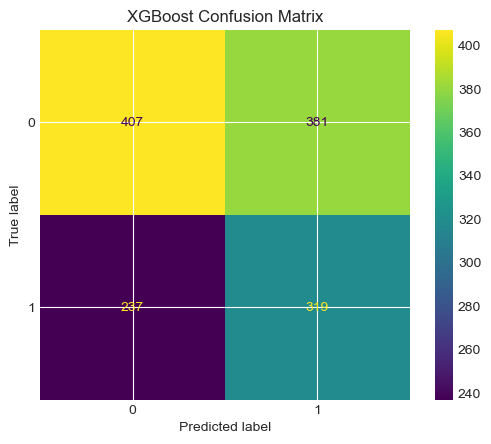

In [19]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 5 Features:")
print(feature_importance.head())

# Classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, xgb.predict(X_test)))

# Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(xgb, X_test, y_test)
plt.title('XGBoost Confusion Matrix')
plt.show()

### Use Predictions for Portfolio

In [ ]:
# Form ML-based weights from features at the START of the test window (point-in-time, no look-ahead).
# Each feature row uses only backward-looking rolling windows, so the row dated at the start of the
# test window knows nothing about the test period's outcomes.
# (Previously weights came from features.iloc[-1:] -- the END of the sample, i.e. future data.)
stock_tickers = [t for t in tickers if t not in ['SPY', 'QQQ']]

preds_oos = {}   # as of start of test window (point-in-time, correct)
preds_eos = {}   # as of end of sample (look-ahead, kept only for the before/after comparison)

for ticker in stock_tickers:
    features = create_features(data, returns, ticker)        # full history of feature rows
    test_features = features[features.index >= split_date]   # rows inside the test window

    if len(test_features) > 0:
        # first available feature row on/after the split date == start of test window
        preds_oos[ticker] = xgb.predict_proba(test_features.iloc[0:1])[0, 1]
    if len(features) > 0:
        preds_eos[ticker] = xgb.predict_proba(features.iloc[-1:])[0, 1]

def to_full_weights(preds):
    """Normalize outperformance probabilities to sum to 1, then expand to all tickers (SPY/AGG-safe)."""
    w_stocks = pd.Series(preds)
    w_stocks = w_stocks / w_stocks.sum()
    w_full = pd.Series(0.0, index=tickers)
    w_full[w_stocks.index] = w_stocks
    return w_stocks, w_full

# Primary (out-of-sample) weights used by the backtest:
ml_weights_stocks, ml_weights_full = to_full_weights(preds_oos)
# End-of-sample weights, kept only to show how much look-ahead inflated the previous result:
ml_weights_stocks_eos, ml_weights_full_eos = to_full_weights(preds_eos)

print("\nML-Based Portfolio Weights (point-in-time, formed at start of test window):")
print(ml_weights_stocks.sort_values(ascending=False))
print(f"\nTotal weight allocated: {ml_weights_stocks.sum():.2f}")
print(f"Weights formed as of test start: {returns[returns.index >= split_date].index[0].date()}")

## Backtest ML Portfolio

In [ ]:
from scipy.optimize import minimize

# Split returns at the same split_date. Evaluation is held fixed on test_returns;
# only the WEIGHTS differ between the previous (look-ahead) and out-of-sample versions.
train_returns = returns[returns.index < split_date]
test_returns = returns[returns.index >= split_date]
print(f"Train window: {train_returns.index[0].date()} to {train_returns.index[-1].date()} ({len(train_returns)} trading days)")
print(f"Test  window: {test_returns.index[0].date()} to {test_returns.index[-1].date()} ({len(test_returns)} trading days)")

def annualized_metrics(daily_returns):
    annual_return = daily_returns.mean() * 252
    annual_vol = daily_returns.std() * np.sqrt(252)
    sharpe = (annual_return - riskFreeRate) / annual_vol  # excess return over risk-free, per unit volatility
    return annual_return, annual_vol, sharpe

# --- Min-variance weights estimated on the TRAIN window only (no future data) ---
cov_train = train_returns.cov() * 252
def _train_volatility(w):
    return np.sqrt(w.T @ cov_train.values @ w)
opt_train = minimize(_train_volatility, equal_weights, method='SLSQP', bounds=bounds, constraints=constraints)
opt_weights_train = opt_train.x

def build_table(ml_w, mv_w, label):
    table = pd.DataFrame({
        'ML Portfolio': annualized_metrics(test_returns @ ml_w),
        'Equal Weight': annualized_metrics(test_returns @ equal_weights),  # 1/N, no estimation -> identical in both versions
        'Min Variance': annualized_metrics(test_returns @ mv_w),
    }, index=['Annual Return', 'Volatility', 'Sharpe Ratio'])
    print(f"\n{label}")
    print("="*60)
    print(table.round(4))
    return table

# PREVIOUS: weights peek at the future (ML from end-of-sample features, MV optimized on full period)
prev = build_table(ml_weights_full_eos, opt_weights, "PREVIOUS (look-ahead weights, evaluated on test window):")

# OUT-OF-SAMPLE: ML weights from start-of-test features, MV optimized on train window only
oos = build_table(ml_weights_full, opt_weights_train, "OUT-OF-SAMPLE (train-only / point-in-time weights):")

# Report how each strategy's Sharpe changes
print("\nSharpe Ratio change: out-of-sample vs previous")
print("="*60)
sharpe_change = pd.DataFrame({
    'Previous Sharpe': prev.loc['Sharpe Ratio'],
    'OOS Sharpe': oos.loc['Sharpe Ratio'],
})
sharpe_change['Change'] = sharpe_change['OOS Sharpe'] - sharpe_change['Previous Sharpe']
print(sharpe_change.round(4))

###  ACF plots of AAPL prices vs returns.

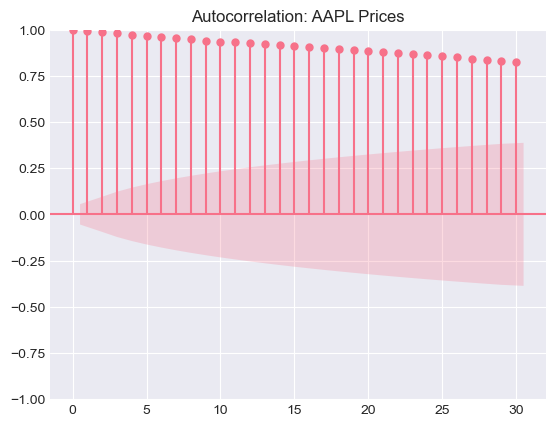

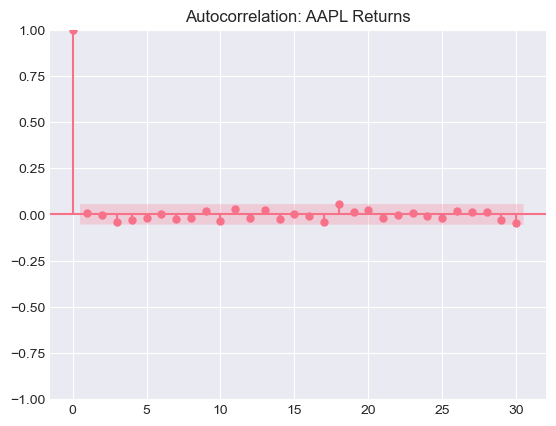

In [22]:
from statsmodels.graphics.tsaplots import plot_acf

# Autocorrelation of PRICES (high)
plot_acf(data['AAPL'].dropna(), lags=30)
plt.title('Autocorrelation: AAPL Prices')
plt.show()

# Autocorrelation of RETURNS (low)
plot_acf(returns['AAPL'].dropna(), lags=30)
plt.title('Autocorrelation: AAPL Returns')
plt.show()